In [ ]:
pip install river

In [ ]:
pip install frouros

In [ ]:
from river import datasets
from river import linear_model, tree
from river import drift, metrics
from river.datasets import synth
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from frouros.metrics import PrequentialError
from sklearn.metrics import mean_squared_error
from frouros.detectors.concept_drift import ADWIN, ADWINConfig

In [ ]:
dataset = synth.FriedmanDrift(
    drift_type='gra',
    position=(2000,2999),
    seed=42)

# Initialize the data containers
data = []
for i, (x, y) in enumerate(dataset):
    x_values = list(x.values())
    data.append(x_values + [y])
    if i >= 2999:  # Limiting to 3000 samples for simplicity
        break

In [ ]:
# Define the column names
column_names = [f'x{i}' for i in range(1, len(x_values) + 1)] + ['y']

In [ ]:
# Create the DataFrame
df = pd.DataFrame(data, columns=column_names)

In [ ]:
train = df.iloc[:1000]
stream = df.iloc[1000:]

In [ ]:
# Create the drift indicator list
drift_position = 1000

In [ ]:
X =train.drop(columns='y').values
y = train['y'].values

In [ ]:
# models
concept1 = LinearRegression()
concept2 = RandomForestRegressor()
concept3 = DecisionTreeRegressor()
concept4 = SVR()

In [ ]:
from sklearn.pipeline import Pipeline

# Define and fit model
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", concept1),
    ]
)
pipeline.fit(X=X, y=y)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR())])

In [ ]:
X_test = stream.drop(columns='y').values
y_test = stream['y'].values

In [ ]:
X_test.shape

(2000, 10)

In [ ]:
# Generate a line chart to compare actual vs predicted values
def generate_line_chart(y_test, y_preds):
    plt.figure(figsize=(14, 4))
    plt.plot(range(len(y_test)), y_test, label="Actual y values", color='blue', linestyle='-')
    plt.plot(range(len(y_preds)), y_preds, label="Predicted y values", color='red', linestyle='--')
    plt.xlabel("Instance Index")
    plt.ylabel("y values")
    plt.title("Line Chart: Actual vs Predicted y values")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Plotting the error values
def plot_error_values(errors):
    plt.figure(figsize=(14, 4))
    plt.plot(range(len(errors)), errors, label="Prequential Error", color='purple')
    plt.xlabel("Instance Index")
    plt.ylabel("Prequential Error")
    plt.title("Behavior of Prequential Error Over data points")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Detector configuration and instantiation
# Initial configuration

results = []

def pipeline_loop(clk,wd,ins,mem):
    config = ADWINConfig(
        clock=clk,   # initially 32
        min_window_size=wd,  # minimum numbers of instances per window to start looking for changes, default to 5
        min_num_instances=ins,  # minimum numbers of instances to start looking for changes, default to 10
        m = mem # controls the amount of memory used and the closeness of the cutpoints checked, default to 5
        # delta is initially 0.002 i.e confidence value, default to 0.002
    )

    detector = ADWIN(config=config)

    detected_drifts = []
    false_alarms = 0
    detection_delays = []
    y_preds = []
    errors = []

    # Metric to compute accuracy
    metric = PrequentialError(alpha=0.9)  # alpha=1.0 is equivalent to normal accuracy

    for i in range(len(X_test)):
        X_i = X_test[i].reshape(1, -1)
        y_i = y_test[i].reshape(1, -1)

        # Predict and calculate the error
        y_pred = pipeline.predict(X_i)
        y_preds.append(y_pred[0])
        error = mean_squared_error(y_true=y_i, y_pred=y_pred)
        metric_error = metric(error_value=error)
        # error = metric(error_value=mean_squared_error(y_true=y_i, y_pred=y_pred))
        errors.append(metric_error)

        # Step 4: Update the drift detector with the current error
        detector.update(value=metric_error)

        # Step 5: Check for detected drift
        if detector.drift:
            # print(f"Change detected at step {i}")
            detected_drifts.append(i)

            # Determine if it's a false alarm or not
            if i < drift_position:  # Compare with the original drift point
                false_alarms += 1
            else:
                detection_delays.append(i - drift_position)
            detector.reset()

    # calculate performance measures
    false_alarm_rate = (false_alarms / (len(X_test) - drift_position)) * 100 if detected_drifts else 0
    detection_delay = int(detection_delays[0]) if detection_delays else None
    combined_measure = (false_alarm_rate + detection_delay)/2 if detection_delay is not None else None
    results.append({
        'parameter_value': mem,
        'False Alarm Rate (%)': false_alarm_rate,
        'Detection Delay': detection_delay,
        'Combined Measure': combined_measure,
        'Detection Delay Indices': detected_drifts
    })

    global temp

    if temp:
      generate_line_chart(y_test, y_preds)
      plot_error_values(errors)
      temp = False

1


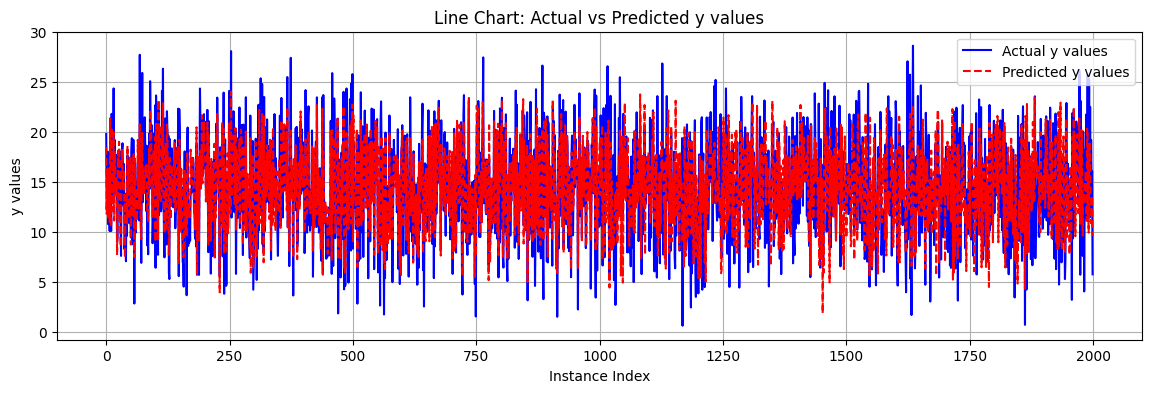

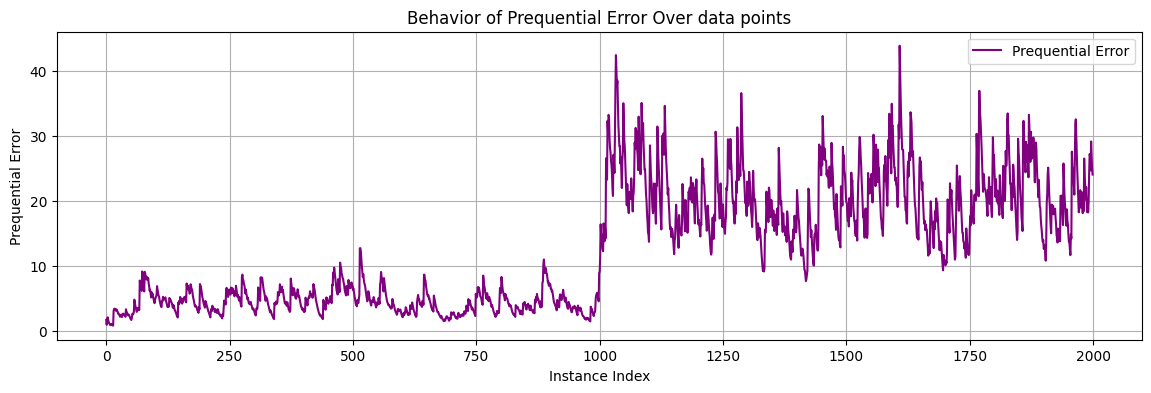

2
3
4
5
6
7
8


/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/stre

9


/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/stre

10


...

/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/stre

100


/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/stre

    parameter_value  False Alarm Rate (%)  Detection Delay  Combined Measure  \
0                 1                   0.0              NaN               NaN   
1                 2                   0.4            119.0             59.70   
2                 3                   0.6             55.0             27.80   
3                 4                   0.6             23.0             11.80   
4                 5                   0.7             55.0             27.85   
..              ...                   ...              ...               ...   
95               96                   0.8             55.0             27.90   
96               97                   0.8             55.0             27.90   
97               98                   0.8             55.0             27.90   
98               99                   0.8             55.0             27.90   
99              100                   0.8             55.0             27.90   

                              Detection

/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (
/usr/local/lib/python3.10/dist-packages/frouros/detectors/concept_drift/streaming/window_based/adwin.py:558: RuntimeWarning: divide by zero encountered in scalar divide
  m_reciprocal = 1 / (w0_instances - min_window_size) + 1 / (


In [ ]:
param_values = []
temp = True

for mem in range(1,101):
  print(mem)
  param_values.append(mem)
  pipeline_loop(32,5,10,mem)

# Convert the results to a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Display the results
print(results_df)

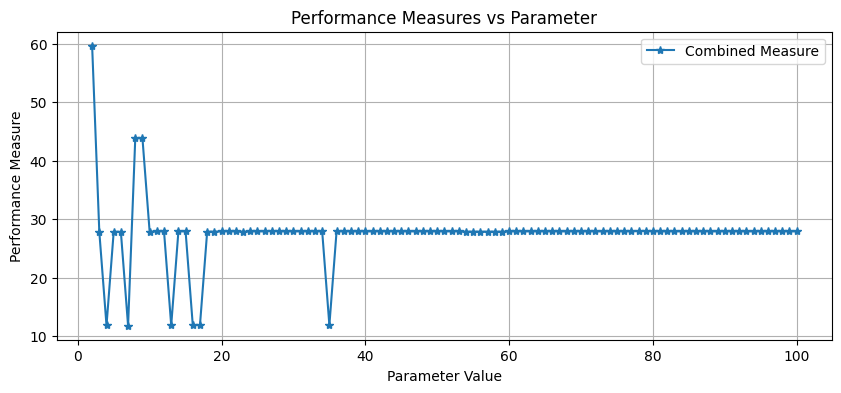

In [ ]:
def plot_parameter_variation(param_values):
  # Example of how to plot the performance measures if needed
  plt.figure(figsize=(10, 4))
  #plt.plot(param_values, results_df['False Alarm Rate (%)'], label='False Alarm Rate (%)', marker='o')
  #plt.plot(param_values, results_df['Detection Delay'], label='Detection Delay', marker='x')
  plt.plot(param_values, results_df['Combined Measure'], label='Combined Measure', marker='*')
  plt.xlabel('Parameter Value')
  plt.ylabel('Performance Measure')
  plt.title('Performance Measures vs Parameter')
  plt.legend()
  plt.grid(True)
  plt.show()

plot_parameter_variation(param_values)

In [ ]:
# Find all indices of the minimum detection delay
min_detection_delay_idx = results_df[results_df['Detection Delay'] == results_df['Detection Delay'].min()].index

# Find all indices of the minimum false alarm rate
min_false_alarm_rate_idx = results_df[results_df['False Alarm Rate (%)'] == results_df['False Alarm Rate (%)'].min()].index

# Find all indices of the minimum combined measure
min_combined_measure_idx = results_df[results_df['Combined Measure'] == results_df['Combined Measure'].min()].index

# Get the corresponding parameter values for each case
params_min_detection_delay = results_df.loc[min_detection_delay_idx, 'parameter_value'].tolist()
params_min_false_alarm_rate = results_df.loc[min_false_alarm_rate_idx, 'parameter_value'].tolist()
param_min_detection_delay_items = results_df.loc[min_detection_delay_idx, 'Detection Delay Indices'].tolist()
params_min_combined_measure = results_df.loc[min_combined_measure_idx, 'parameter_value'].tolist()

# Print the results
print(f"Parameters with minimum detection delay: {params_min_detection_delay}")
print(f"Parameters with minimum false alarm rate: {params_min_false_alarm_rate}")
print(f"Parameters with minimum combined measure: {params_min_combined_measure}")

Parameters with minimum detection delay: [4, 7, 13, 16, 17, 35]
Parameters with minimum false alarm rate: [1]
Parameters with minimum combined measure: [7]


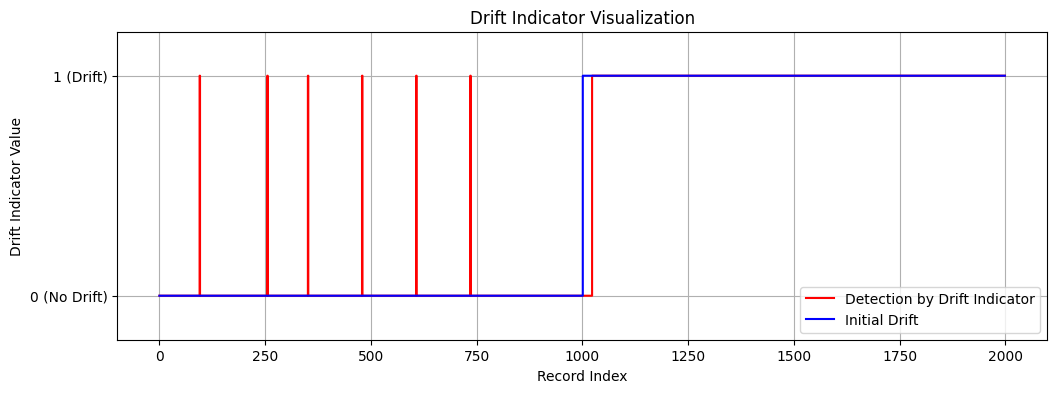

In [ ]:
def plot_drift(detected_drifts):
    # binary array for initial drift
    drift_indicator = np.zeros(len(data) - drift_position)
    first_drift_found = False

    for drift_point in detected_drifts:
        # Check if drift_point is at or after drift_position and if it's the first drift point after drift_position
        if drift_point < drift_position:
            # Set drift_indicator to 1 starting from the position of the first detected drift after drift_position
            drift_indicator[drift_point] = 1  # Fill from this index onward with 1s
        elif drift_point >= drift_position and not first_drift_found:
            drift_indicator[drift_point:] = 1  # Fill from this index onward with 1s
            first_drift_found = True
        else:
            continue

    drift_creator = np.ones(len(data)-drift_position)
    for i in range(drift_position,-1,-1):
        drift_creator[i] = 0

    # Visualize the drift indicator
    plt.figure(figsize=(12, 4))
    plt.plot(drift_indicator, drawstyle='steps-post', color='red', label='Detection by Drift Indicator')
    plt.plot(drift_creator, drawstyle='steps-post', color='blue', label='Initial Drift')
    # plt.axvline(x=drift_position-1000, color='red', linestyle='--', label='Drift Point')

    plt.title('Drift Indicator Visualization')
    plt.xlabel('Record Index')
    plt.ylabel('Drift Indicator Value')
    plt.ylim(-0.2, 1.2)
    plt.yticks([0, 1], labels=['0 (No Drift)', '1 (Drift)'])
    plt.legend()
    plt.grid(True)
    plt.show()

plot_drift(param_min_detection_delay_items[0])
